# 03 — With PM vs. cross-basket, no PM

**Why:** a plausible-sounding alternative to PM — skip the dedicated rebalancer, just let ordinary profit-seeking pools arbitrage every pair against each other, and see if the wallet ends up balanced anyway "for free."

With PM: same arbitrageur + organic-flow setup as `02` (`pm_fee=2%`). No PM: an independent, isolated pool on every pairwise token combination (WETH/USDC, WETH/USDT, USDC/USDT), each unaware of the others, trying to balance the wallet with no PM and no Guard.</cell id="785dfe4b">

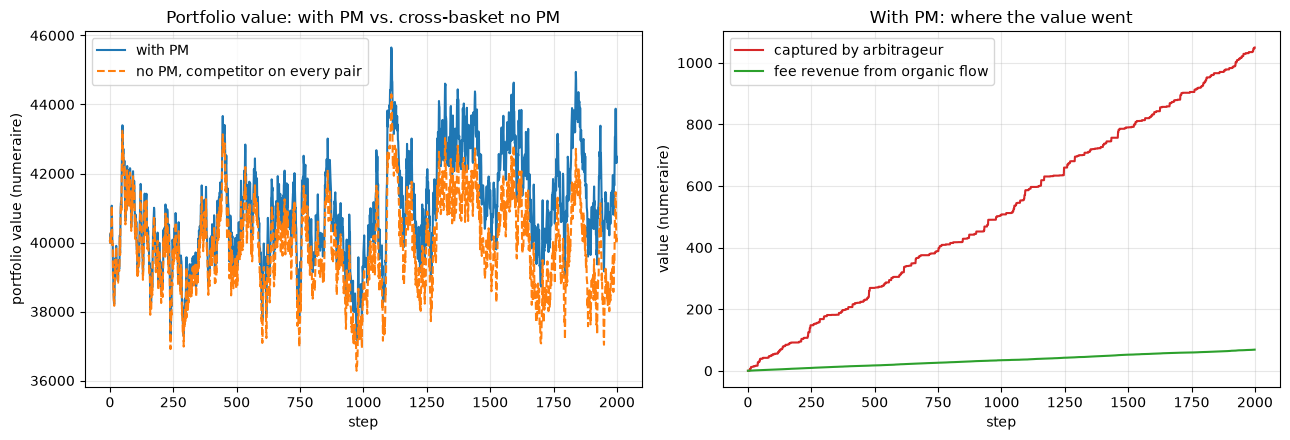

final value: with PM = 42,486, no PM (cross-basket) = 40,138
mean tracking error: with PM = 0.3735%, no PM (cross-basket) = 0.6594%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from aqua_sim.scenarios import basket_with_without_pm, cross_basket_no_pm
from aqua_sim.price_process import MeanRevertingPriceProcess

N_STEPS = 2000
PROFITABLE_PM = dict(pm_fee=0.02, organic_arrival_prob_per_step=0.8, organic_fee=0.003, organic_mean_size_fraction=0.001)


def run_pair(seed):
    mr_with = MeanRevertingPriceProcess(token_id="WETH", sigma_per_step=0.02, mean_price=2000.0, kappa=0.05, initial_price=2000.0, seed=seed)
    world_with = basket_with_without_pm.build_world(with_pm=True, weth_price_process=mr_with, seed=seed, **PROFITABLE_PM)
    world_with.run(N_STEPS)

    mr_no_pm = MeanRevertingPriceProcess(token_id="WETH", sigma_per_step=0.02, mean_price=2000.0, kappa=0.05, initial_price=2000.0, seed=seed)
    world_no_pm = cross_basket_no_pm.build_world(weth_price_process=mr_no_pm, seed=seed)
    world_no_pm.run(N_STEPS)
    return world_with, world_no_pm


world_with, world_no_pm = run_pair(seed=0)

total_with = np.array(world_with.metrics.value_a_path) + np.array(world_with.metrics.value_b_path)
total_no_pm = np.array(world_no_pm.metrics.value_a_path) + np.array(world_no_pm.metrics.value_b_path)
arb_captured = np.array(world_with.metrics.captured_value_paths["arbitrageur"])
organic_captured = np.array(world_with.metrics.captured_value_paths["organic_weth_usdc"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(total_with, label="with PM")
ax1.plot(total_no_pm, label="no PM, competitor on every pair", linestyle="--")
ax1.set_xlabel("step")
ax1.set_ylabel("portfolio value (numeraire)")
ax1.set_title("Portfolio value: with PM vs. cross-basket no PM")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(arb_captured, label="captured by arbitrageur", color="tab:red")
ax2.plot(-organic_captured, label="fee revenue from organic flow", color="tab:green")
ax2.set_xlabel("step")
ax2.set_ylabel("value (numeraire)")
ax2.set_title("With PM: where the value went")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"final value: with PM = {total_with[-1]:,.0f}, no PM (cross-basket) = {total_no_pm[-1]:,.0f}")

te_with = np.mean(world_with.metrics.tracking_error_path)
te_no_pm = np.mean(world_no_pm.metrics.tracking_error_path)
print(f"mean tracking error: with PM = {te_with:.4%}, no PM (cross-basket) = {te_no_pm:.4%}")


In [2]:
final_with, final_no_pm, te_with_list, te_no_pm_list = [], [], [], []
for seed in range(10):
    w_with, w_no_pm = run_pair(seed=seed)
    final_with.append(w_with.metrics.value_a_path[-1] + w_with.metrics.value_b_path[-1])
    final_no_pm.append(w_no_pm.metrics.value_a_path[-1] + w_no_pm.metrics.value_b_path[-1])
    te_with_list.append(np.mean(w_with.metrics.tracking_error_path))
    te_no_pm_list.append(np.mean(w_no_pm.metrics.tracking_error_path))

final_with, final_no_pm = np.array(final_with), np.array(final_no_pm)
te_with_arr, te_no_pm_arr = np.array(te_with_list), np.array(te_no_pm_list)
print(f"mean final value: with PM = {final_with.mean():,.0f}, no PM = {final_no_pm.mean():,.0f}")
print(f"mean tracking error: with PM = {te_with_arr.mean():.4%}, no PM = {te_no_pm_arr.mean():.4%}")


mean final value: with PM = 43,073, no PM = 40,646
mean tracking error: with PM = 0.3689%, no PM = 0.6713%


**Result:** no — it doesn't, though the gap is a real, structural difference, not a "wildly worse" one: mean tracking error is ~0.67% without PM vs. ~0.37% with it, about 1.8x worse. Each isolated pool only enforces its *own* pair's price consistency; none of them knows or cares about the wallet's declared 50/50 target. Arbitrage keeps prices consistent — it doesn't substitute for a strategy that actually holds a target.